# Importación de las librerías

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import Perceptron

In [3]:
df = pd.read_csv('../dataset/Spalling data.csv')
df.head()

,Source,W/B,CA/B,FA/B,F/B,GGBS/B,SF/B,Sa,AggType,FiberType,...,SpecVol,Age,CS_28d,CS_Aged,TS_Aged,Out,MassLoss,NomDepth,MaxDepth,SpallType
0,[12],0.3,2.000,1.049,0.0,0.25,0.0,7.0,Basalt,0,...,1.8,44.0,69.70,NaN,NaN,1.0,32.49,82,NaN,Explosive
1,NaN,0.3,1.374,1.199,0.0,0.25,0.0,7.0,Granite,0,...,1.8,87.0,69.67,NaN,NaN,1.0,35.51,89.63,NaN,Explosive
2,NaN,0.3,1.374,1.199,0.0,0.25,0.0,7.0,Granite,0,...,1.8,89.0,69.67,NaN,NaN,1.0,22.88,57.74,NaN,Explosive
3,NaN,0.3,2.000,1.049,0.0,0.25,0.0,14.0,Basalt,0,...,1.8,67.0,69.40,NaN,NaN,1.0,7.48,18.88,NaN,Explosive
4,NaN,0.3,1.502,1.307,0.0,0.25,0.0,14.0,Granite,0,...,1.8,83.0,68.70,NaN,NaN,1.0,23.4,59.06,NaN,Explosive


# 0 Descripción del DataSet

In [4]:
#número de registros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Source     55 non-null     object 
 1   W/B        1430 non-null   float64
 2   CA/B       1406 non-null   float64
 3   FA/B       1406 non-null   float64
 4   F/B        1430 non-null   float64
 5   GGBS/B     1430 non-null   float64
 6   SF/B       1415 non-null   float64
 7   Sa         1424 non-null   float64
 8   AggType    732 non-null    object 
 9   FiberType  1430 non-null   object 
 10  FiberVol   1430 non-null   object 
 11  FiberLen   1421 non-null   object 
 12  FiberRad   1406 non-null   object 
 13  Slump      376 non-null    float64
 14  Moist      808 non-null    float64
 15  Air        168 non-null    float64
 16  YoungMod   304 non-null    float64
 17  Dens       325 non-null    float64
 18  HrRate     1415 non-null   float64
 19  Tmax       1430 non-null   int64  
 20  Time    

## Variables
**Identificadores (categóricas)**

* Source: identificador del estudio. Sirve para agrupar por paper o experimento.

* AggType: tipo de agregado.

* FiberType: tipo de fibra.


* SpallType: tipo de desconchado.

**Composición del material (tipo “X/B”)**

B indica el aglutinante/binder:

* W/B: relación agua / aglutinante.

* CA/B: relación agregado grueso / aglutinante.

* FA/B: relación agregado fino / aglutinante.

* F/B: relación de algún componente F respecto al binder.

* GGBS/B: relación escoria (GGBS) / aglutinante.

* SF/B: relación sílice fume / aglutinante.


**Fibra**

* FiberVol: volumen de fibra (fracción o %).

* FiberLen: longitud de fibra.

* FiberRad: radio de fibra (o espesor característico).

**Estado fresco/condiciones iniciales**

* Slump: revenimiento (slump) de la mezcla.

* Moist: contenido de humedad.

* Air: contenido de aire.

**Propiedades mecánicas/físicas**

* YoungMod: módulo de Young.

* Dens: densidad.

* Age: edad de la muestra (prob. días).

* CS_28d: resistencia a compresión a 28 días.

* CS_Aged: resistencia a compresión a la edad del ensayo.

* TS_Aged: resistencia a tensión a la edad del ensayo.

* Exposición térmica / fuego

* HrRate: tasa de calentamiento.

* Tmax: temperatura máxima.

* Time: tiempo de exposición

* StressLvl: nivel de esfuerzo/carga aplicada durante el calentamiento.

**Geometría / tamaño de muestra**

* Diam: diámetro (si la muestra es cilíndrica o equivalente).

* ExpArea: área expuesta (al fuego).

* SpecVol: volumen del espécimen.

* Variables objetivo / daño por spalling

* MassLoss: pérdida de masa (post-incendio/ensayo).

* NomDepth: profundidad nominal de spalling.

* MaxDepth: profundidad máxima de spalling.

**Variable Objetivo**
* Out: variable categórica de salida/resultado.

# 1 Limpieza inicial

In [5]:
# 2) Vista general
print("Dimensión inicial:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensión inicial: (1430, 34)

Tipos de datos:
Source        object
W/B          float64
CA/B         float64
FA/B         float64
F/B          float64
GGBS/B       float64
SF/B         float64
Sa           float64
AggType       object
FiberType     object
FiberVol      object
FiberLen      object
FiberRad      object
Slump        float64
Moist        float64
Air          float64
YoungMod     float64
Dens         float64
HrRate       float64
Tmax           int64
Time         float64
Diam         float64
ExpArea      float64
StressLvl    float64
SpecVol      float64
Age          float64
CS_28d       float64
CS_Aged      float64
TS_Aged      float64
Out          float64
MassLoss      object
NomDepth      object
MaxDepth      object
SpallType     object
dtype: object


In [6]:
print("\nValores faltantes por columna:")
print(df.isnull().sum().sort_values(ascending=False))


Valores faltantes por columna:
StressLvl    1384
MaxDepth     1383
Source       1375
ExpArea      1333
NomDepth     1320
Air          1262
TS_Aged      1256
SpallType    1179
CS_Aged      1171
YoungMod     1126
Dens         1105
Slump        1054
MassLoss      862
AggType       698
Moist         622
CS_28d        311
Time          229
Age           164
Out            40
FiberRad       24
CA/B           24
FA/B           24
SF/B           15
HrRate         15
FiberLen        9
Sa              6
SpecVol         3
W/B             0
GGBS/B          0
FiberType       0
FiberVol        0
F/B             0
Tmax            0
Diam            0
dtype: int64


In [7]:
#Porcentaje de valores vacíos por columna
porcentaje_vacios = (df.isna().sum() / len(df)) * 100
print(porcentaje_vacios)

Source       96.153846
W/B           0.000000
CA/B          1.678322
FA/B          1.678322
F/B           0.000000
GGBS/B        0.000000
SF/B          1.048951
Sa            0.419580
AggType      48.811189
FiberType     0.000000
FiberVol      0.000000
FiberLen      0.629371
FiberRad      1.678322
Slump        73.706294
Moist        43.496503
Air          88.251748
YoungMod     78.741259
Dens         77.272727
HrRate        1.048951
Tmax          0.000000
Time         16.013986
Diam          0.000000
ExpArea      93.216783
StressLvl    96.783217
SpecVol       0.209790
Age          11.468531
CS_28d       21.748252
CS_Aged      81.888112
TS_Aged      87.832168
Out           2.797203
MassLoss     60.279720
NomDepth     92.307692
MaxDepth     96.713287
SpallType    82.447552
dtype: float64


In [8]:
print("\nDuplicados exactos:", df.duplicated().sum())

print("\nDistribución de la variable objetivo Out:")
print(df["Out"].value_counts(dropna=False))


Duplicados exactos: 4

Distribución de la variable objetivo Out:
Out
0.0    1070
1.0     320
NaN      40
Name: count, dtype: int64


In [9]:
# Copia de trabajo
df_clean = df.copy()

In [10]:
#Eliminar filas donde la variable objetivo está vacía
df_clean = df_clean.dropna(subset=["Out"])

In [11]:
#Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

In [12]:
# porque parece más una referencia bibliográfica que una variable física del concreto
if "Source" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Source"])

print("Dimensión después de limpieza básica:", df_clean.shape)

Dimensión después de limpieza básica: (1386, 33)


In [13]:
# Columnas que deben ser numéricas
cols_numericas_forzadas = ["MassLoss", "NomDepth", "MaxDepth", "FiberVol", "FiberLen", "FiberRad"]

#errors="coerce" en caso de encuentrar un valor raro que no puede convertirse lo pondrá en NaN.
for col in cols_numericas_forzadas:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("\nTipos de datos después de conversión:")
print(df_clean.dtypes)


Tipos de datos después de conversión:
W/B          float64
CA/B         float64
FA/B         float64
F/B          float64
GGBS/B       float64
SF/B         float64
Sa           float64
AggType       object
FiberType     object
FiberVol     float64
FiberLen     float64
FiberRad     float64
Slump        float64
Moist        float64
Air          float64
YoungMod     float64
Dens         float64
HrRate       float64
Tmax           int64
Time         float64
Diam         float64
ExpArea      float64
StressLvl    float64
SpecVol      float64
Age          float64
CS_28d       float64
CS_Aged      float64
TS_Aged      float64
Out          float64
MassLoss     float64
NomDepth     float64
MaxDepth     float64
SpallType     object
dtype: object


## Varibale objetivo

In [14]:
print("\nDistribución final de Out:")
print(df_clean["Out"].value_counts())

# Asegurarnos que Out sea entero
df_clean["Out"] = df_clean["Out"].astype(int)

print("\nTipo de dato de Out:", df_clean["Out"].dtype)


Distribución final de Out:
Out
0.0    1066
1.0     320
Name: count, dtype: int64

Tipo de dato de Out: int64


# 2 Definición de variables y preparación para el preprocesamiento

In [15]:
# Variable objetivo
y = df_clean["Out"]

# Variables predictoras
X = df_clean.drop(columns=["Out"])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1386, 32)
Dimensión de y: (1386,)


## Identificar variables númericas y categicas

In [16]:
# Identificar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Columnas numéricas:")
print(num_cols)

print("\nColumnas categóricas:")
print(cat_cols)

Columnas numéricas:
['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B', 'SF/B', 'Sa', 'FiberVol', 'FiberLen', 'FiberRad', 'Slump', 'Moist', 'Air', 'YoungMod', 'Dens', 'HrRate', 'Tmax', 'Time', 'Diam', 'ExpArea', 'StressLvl', 'SpecVol', 'Age', 'CS_28d', 'CS_Aged', 'TS_Aged', 'MassLoss', 'NomDepth', 'MaxDepth']

Columnas categóricas:
['AggType', 'FiberType', 'SpallType']


In [17]:
df_valoresFaltantes = pd.DataFrame({
    "faltantes": X.isnull().sum(),
    "porcentaje": (X.isnull().sum() / len(X)) * 100,
    "tipo": X.dtypes.astype(str)
}).sort_values(by="porcentaje", ascending=False)

print(df_valoresFaltantes)

           faltantes  porcentaje     tipo
MaxDepth        1340   96.681097  float64
StressLvl       1340   96.681097  float64
ExpArea         1289   93.001443  float64
NomDepth        1281   92.424242  float64
Air             1218   87.878788  float64
TS_Aged         1214   87.590188  float64
CS_Aged         1148   82.828283  float64
SpallType       1135   81.890332   object
YoungMod        1082   78.066378  float64
Dens            1079   77.849928  float64
Slump           1013   73.088023  float64
MassLoss         819   59.090909  float64
AggType          680   49.062049   object
Moist            584   42.135642  float64
FiberRad         293   21.139971  float64
FiberLen         293   21.139971  float64
CS_28d           289   20.851371  float64
FiberVol         213   15.367965  float64
Time             212   15.295815  float64
Age              164   11.832612  float64
FA/B              24    1.731602  float64
CA/B              24    1.731602  float64
HrRate            15    1.082251  

In [18]:
# Umbral de faltantes
umbral_faltantes = 21

cols_nulos = df_valoresFaltantes[df_valoresFaltantes["porcentaje"] > umbral_faltantes].index.tolist()

print(f"Columnas con más de {umbral_faltantes}% de faltantes:")
print(cols_nulos)

Columnas con más de 21% de faltantes:
['MaxDepth', 'StressLvl', 'ExpArea', 'NomDepth', 'Air', 'TS_Aged', 'CS_Aged', 'SpallType', 'YoungMod', 'Dens', 'Slump', 'MassLoss', 'AggType', 'Moist', 'FiberRad', 'FiberLen']


## Eliminar variables con mayor a 20% de datos

In [19]:
# Eliminar columnas con demasiados faltantes
X_reduced = X.drop(columns=cols_nulos)

print("Dimensión de X después de eliminar columnas con muchos nulos:", X_reduced.shape)
print("Columnas restantes:")
print(X_reduced.columns.tolist())

Dimensión de X después de eliminar columnas con muchos nulos: (1386, 16)
Columnas restantes:
['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B', 'SF/B', 'Sa', 'FiberType', 'FiberVol', 'HrRate', 'Tmax', 'Time', 'Diam', 'SpecVol', 'Age', 'CS_28d']


In [20]:
num_cols = X_reduced.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_reduced.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Columnas numéricas finales:")
print(num_cols)

print("\nColumnas categóricas finales:")
print(cat_cols)

Columnas numéricas finales:
['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B', 'SF/B', 'Sa', 'FiberVol', 'HrRate', 'Tmax', 'Time', 'Diam', 'SpecVol', 'Age', 'CS_28d']

Columnas categóricas finales:
['FiberType']


In [21]:
for col in cat_cols:
    print(f"\nColumna: {col}")
    print(X_reduced[col].value_counts(dropna=False).head(10))


Columna: FiberType
FiberType
0        707
PP       142
SF       124
SF+PP    112
SF+FF     63
NY+PP     40
PVA       26
PP+PE     25
FF        21
JF        18
Name: count, dtype: int64


In [22]:
# Guardar las variables de X_reduced en df_clean
df_clean = X_reduced.copy()
df_clean["Out"] = y

print("Dimensión de df_clean después de actualizar:")
print(df_clean.shape)
print("\nColumnas de df_clean:")
print(df_clean.columns.tolist())

Dimensión de df_clean después de actualizar:
(1386, 17)

Columnas de df_clean:
['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B', 'SF/B', 'Sa', 'FiberType', 'FiberVol', 'HrRate', 'Tmax', 'Time', 'Diam', 'SpecVol', 'Age', 'CS_28d', 'Out']


In [23]:
df_clean

,W/B,CA/B,FA/B,F/B,GGBS/B,SF/B,Sa,FiberType,FiberVol,HrRate,Tmax,Time,Diam,SpecVol,Age,CS_28d,Out
0,0.30,2.000,1.049,0.0,0.25,0.0,7.0,0,0.00,101.0,1034,NaN,100.0,1.8000,44.0,69.70,1
1,0.30,1.374,1.199,0.0,0.25,0.0,7.0,0,0.00,101.0,1034,NaN,100.0,1.8000,87.0,69.67,1
2,0.30,1.374,1.199,0.0,0.25,0.0,7.0,0,0.00,101.0,1034,NaN,100.0,1.8000,89.0,69.67,1
3,0.30,2.000,1.049,0.0,0.25,0.0,14.0,0,0.00,101.0,1034,NaN,100.0,1.8000,67.0,69.40,1
4,0.30,1.502,1.307,0.0,0.25,0.0,14.0,0,0.00,101.0,1034,NaN,100.0,1.8000,83.0,68.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,0.45,NaN,NaN,0.0,0.00,0.0,8.0,PP,1.22,66.0,678,1.0,22.5,0.0054,195.0,53.60,0
1426,0.45,NaN,NaN,0.0,0.00,0.0,8.0,PP,2.22,66.0,678,1.0,22.5,0.0054,196.0,53.60,0
1427,0.45,NaN,NaN,0.0,0.00,0.0,8.0,0,0.00,66.0,678,1.0,22.5,0.0054,190.0,54.90,1
1428,0.45,NaN,NaN,0.0,0.00,0.0,8.0,0,0.00,66.0,678,1.0,22.5,0.0054,190.0,54.90,0


Una vez realizada la limpieza inicial, se definió la variable objetivo Out, la cual representa la ocurrencia del fenómeno de spalling en el concreto. A partir de ello, el conjunto de datos se separó en dos componentes: el vector objetivo y, correspondiente a la variable de salida, y la matriz de predictores X, integrada por las variables restantes.

Posteriormente, se identificaron las variables numéricas y categóricas con el propósito de establecer un tratamiento diferenciado en etapas posteriores del preprocesamiento. Adicionalmente, se llevó a cabo un análisis del porcentaje de valores faltantes por columna, lo que permitió detectar variables con una proporción excesiva de datos ausentes. Con base en este análisis, se evaluó la eliminación de aquellas columnas con un nivel de faltantes considerable, priorizando la conservación de variables con suficiente información y potencial relevancia para la predicción.

# 3 preprocesamiento y transformación de datos

In [24]:
df_clean.head()

,W/B,CA/B,FA/B,F/B,GGBS/B,SF/B,Sa,FiberType,FiberVol,HrRate,Tmax,Time,Diam,SpecVol,Age,CS_28d,Out
0,0.3,2.000,1.049,0.0,0.25,0.0,7.0,0,0.0,101.0,1034,NaN,100.0,1.8,44.0,69.70,1
1,0.3,1.374,1.199,0.0,0.25,0.0,7.0,0,0.0,101.0,1034,NaN,100.0,1.8,87.0,69.67,1
2,0.3,1.374,1.199,0.0,0.25,0.0,7.0,0,0.0,101.0,1034,NaN,100.0,1.8,89.0,69.67,1
3,0.3,2.000,1.049,0.0,0.25,0.0,14.0,0,0.0,101.0,1034,NaN,100.0,1.8,67.0,69.40,1
4,0.3,1.502,1.307,0.0,0.25,0.0,14.0,0,0.0,101.0,1034,NaN,100.0,1.8,83.0,68.70,1


In [25]:
# Separar variables predictoras y objetivo
X = df_clean.drop(columns=["Out"])
y = df_clean["Out"]

In [26]:
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1386, 16)
Dimensión de y: (1386,)


## Separar en train y test

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1108, 16)
X_test: (278, 16)
y_train: (1108,)
y_test: (278,)


In [28]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Columnas numéricas:")
print(num_cols)

print("\nColumnas categóricas:")
print(cat_cols)

Columnas numéricas:
['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B', 'SF/B', 'Sa', 'FiberVol', 'HrRate', 'Tmax', 'Time', 'Diam', 'SpecVol', 'Age', 'CS_28d']

Columnas categóricas:
['FiberType']


In [29]:
# Pipeline numérico
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor general
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['W/B', 'CA/B', 'FA/B', 'F/B', 'GGBS/B',
                                  'SF/B', 'Sa', 'FiberVol', 'HrRate', 'Tmax',
                                  'Time', 'Diam', 'SpecVol', 'Age', 'CS_28d']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['FiberType'])])


* SimpleImputer(strategy="median")

    Rellena faltantes en variables numéricas con la mediana.

    Esto suele ser mejor que la media cuando hay valores extremos.

* StandardScaler()

    Estandariza las variables numéricas para que queden en una escala comparable. Esto ayuda mucho a modelos como:

    * Regresión logística
    * KNN
    * SVM

* SimpleImputer(strategy="most_frequent")

    Rellena faltantes en categóricas con la categoría más frecuente.

* OneHotEncoder(handle_unknown="ignore")
    
    Convierte variables categóricas en columnas binarias. La opción handle_unknown="ignore" evita errores si en prueba aparece una categoría no vista en entrenamiento.

In [30]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Forma de X_train procesado:", X_train_processed.shape)
print("Forma de X_test procesado:", X_test_processed.shape)

Forma de X_train procesado: (1108, 44)
Forma de X_test procesado: (278, 44)


In [31]:
feature_names = preprocessor.get_feature_names_out()
print("Número total de variables después de transformar:", len(feature_names))
print(feature_names[:20])  # mostrar primeras 20

Número total de variables después de transformar: 44
['num__W/B' 'num__CA/B' 'num__FA/B' 'num__F/B' 'num__GGBS/B' 'num__SF/B'
 'num__Sa' 'num__FiberVol' 'num__HrRate' 'num__Tmax' 'num__Time'
 'num__Diam' 'num__SpecVol' 'num__Age' 'num__CS_28d' 'cat__FiberType_0'
 'cat__FiberType_BF' 'cat__FiberType_CF' 'cat__FiberType_CF+PP'
 'cat__FiberType_CF+SF']


# 4 Modelos sin hiperparametros

In [32]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Perceptrón": Perceptron(random_state=42)
}

In [33]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]

## Función para correr los modelos con validación cruzada

In [34]:
def evaluar_modelos(modelos, preprocessor, X_train, y_train, cv, metricas):
    resultados = []
    
    for nombre, modelo in modelos.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", modelo)
        ])
        
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=metricas,
            n_jobs=-1
        )
        
        resultados.append({
            "Modelo": nombre,
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1-score": scores["test_f1"].mean(),
            "ROC-AUC": scores["test_roc_auc"].mean()
        })
    
    return pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)

In [35]:
df_resultados = evaluar_modelos(
    modelos=modelos,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    metricas=metricas
)

df_resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Árbol de Decisión,0.872703,0.732850,0.710923,0.719030,0.822464
1,KNN,0.862826,0.734222,0.645077,0.679541,0.917462
3,SVM,0.849287,0.761094,0.508308,0.602728,0.917310
5,Perceptrón,0.787838,0.565394,0.562615,0.552304,0.816896
0,Regresión Logística,0.827584,0.716092,0.440769,0.534028,0.889492
2,Naive Bayes,0.317666,0.247999,0.960615,0.394187,0.564332


* Accuracy: Qué porcentaje total de predicciones fueron correctas.
* Precision: De todos los casos que el modelo predijo como spalling, cuántos sí eran spalling.
* **Recall: De todos los casos reales de spalling, cuántos logró detectar.**
* F1-score: Es el balance entre precision y recall.
* ROC-AUC: Mide qué tan bien separa las clases en general.

De acuerdo con los resultados obtenidos mediante validación cruzada, el modelo de árbol de decisión presentó el mejor desempeño general, al alcanzar el mayor valor de F1-score (0.7190), acompañado de una precisión de 0.7329 y un recall de 0.7109. Esto sugiere que el modelo logra un equilibrio adecuado entre la identificación correcta de casos de spalling y el control de falsos positivos.

El modelo KNN ocupó el segundo lugar en desempeño, mientras que SVM mostró valores altos de ROC-AUC, aunque con menor capacidad para recuperar la clase positiva. Por otro lado, Naive Bayes alcanzó el recall más alto, pero con una precisión y exactitud muy bajas, lo que indica una tendencia a sobrepredecir la ocurrencia de spalling. En consecuencia, el árbol de decisión se selecciona como el candidato principal para la siguiente etapa de evaluación sobre el conjunto de prueba.

## Función para los modelos en test 

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluar_modelos_test(modelos, preprocessor, X_train, y_train, X_test, y_test):
    resultados_test = []
    
    for nombre, modelo in modelos.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", modelo)
        ])
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        
        if hasattr(pipeline, "predict_proba"):
            y_score = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_score)
        elif hasattr(pipeline, "decision_function"):
            y_score = pipeline.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)
        else:
            roc_auc = np.nan
        
        resultados_test.append({
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc
        })
    
    return pd.DataFrame(resultados_test).sort_values(by="F1-score", ascending=False)

In [37]:
df_resultados_test = evaluar_modelos_test(
    modelos=modelos,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

df_resultados_test

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Árbol de Decisión,0.892086,0.774194,0.750000,0.761905,0.841706
1,KNN,0.852518,0.682540,0.671875,0.677165,0.905885
5,Perceptrón,0.823741,0.597403,0.718750,0.652482,0.865326
3,SVM,0.852518,0.755556,0.531250,0.623853,0.910667
0,Regresión Logística,0.848921,0.775000,0.484375,0.596154,0.911544
2,Naive Bayes,0.309353,0.239837,0.921875,0.380645,0.591341


Los resultados obtenidos sobre el conjunto de prueba confirmaron que el árbol de decisión fue el modelo con mejor desempeño global. Este clasificador alcanzó una exactitud de 0.8921, una precisión de 0.7742, un recall de 0.7500 y el F1-score más alto (0.7619) entre todos los modelos evaluados. Estos resultados indican que el modelo logró un equilibrio adecuado entre la detección de casos positivos de spalling y el control de falsos positivos.

Además, el comportamiento del árbol de decisión fue consistente con los resultados observados durante la validación cruzada, lo que sugiere una buena capacidad de generalización. Aunque modelos como KNN y SVM presentaron valores altos de ROC-AUC, sus valores de recall y F1-score fueron inferiores. Por su parte, Naive Bayes mostró un recall muy elevado, pero acompañado de una precisión y exactitud bajas, evidenciando una tendencia a sobrepredecir la clase positiva. En consecuencia, el árbol de decisión se seleccionó como el modelo más adecuado para la clasificación de la ocurrencia de spalling en concreto.

## Graficas de los modelos

### Árbol de Decisión

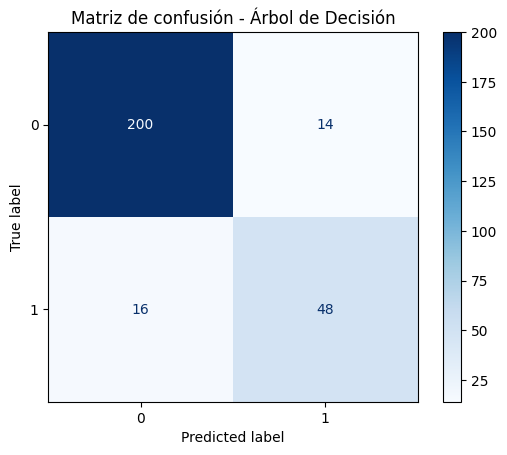

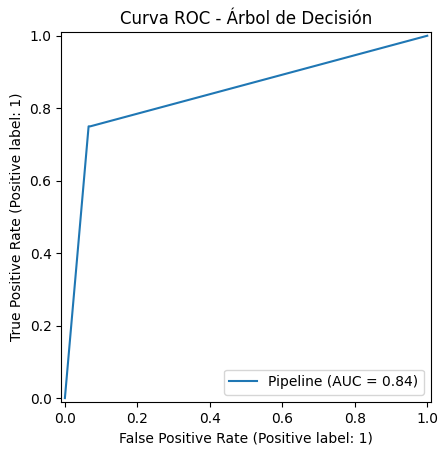

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix

# Pipeline del modelo
pipeline_tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Entrenar
pipeline_tree.fit(X_train, y_train)

# Predicción
y_pred_tree = pipeline_tree.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

# Curva ROC
RocCurveDisplay.from_estimator(pipeline_tree, X_test, y_test)
plt.title("Curva ROC - Árbol de Decisión")
plt.show()

### KNN

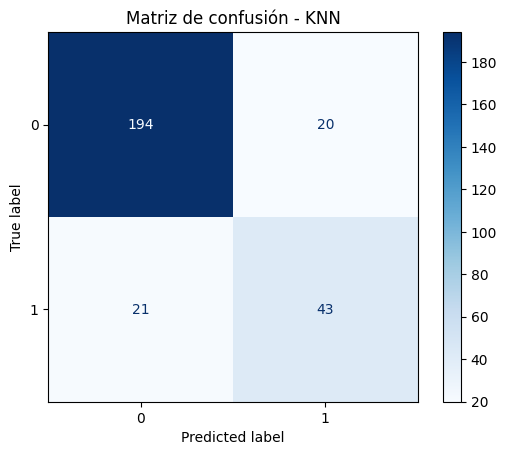

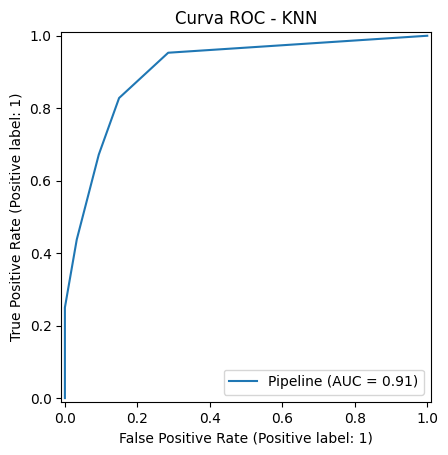

In [39]:
pipeline_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - KNN")
plt.show()

RocCurveDisplay.from_estimator(pipeline_knn, X_test, y_test)
plt.title("Curva ROC - KNN")
plt.show()

### SVM

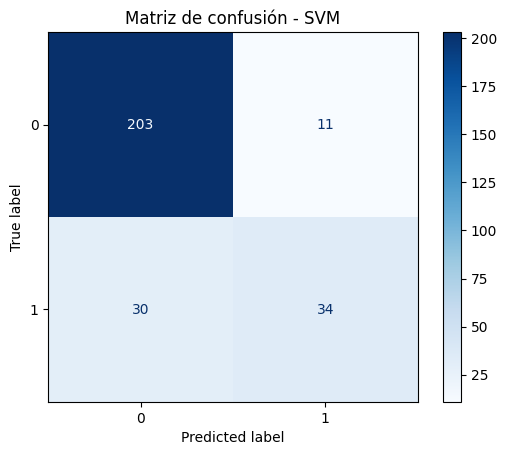

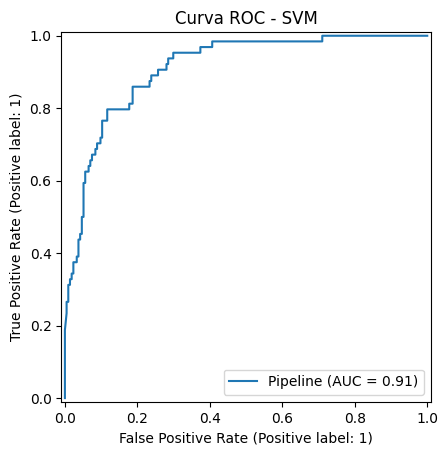

In [40]:

pipeline_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - SVM")
plt.show()

RocCurveDisplay.from_estimator(pipeline_svm, X_test, y_test)
plt.title("Curva ROC - SVM")
plt.show()

### Función para matriz de confusión y Curva de ROC

Para complementar la evaluación cuantitativa de los clasificadores, se generaron matrices de confusión y curvas ROC sobre el conjunto de prueba. La matriz de confusión permitió identificar la cantidad de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos obtenidos por cada modelo. Por su parte, la curva ROC permitió analizar la capacidad de separación entre clases, mientras que el área bajo la curva (AUC) proporcionó una medida global del desempeño discriminativo del clasificador.

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix
import matplotlib.pyplot as plt

def mostrar_matriz_y_roc(nombre_modelo, modelo, preprocessor, X_train, y_train, X_test, y_test):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()
    
    # Curva ROC
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
    plt.title(f"Curva ROC - {nombre_modelo}")
    plt.show()

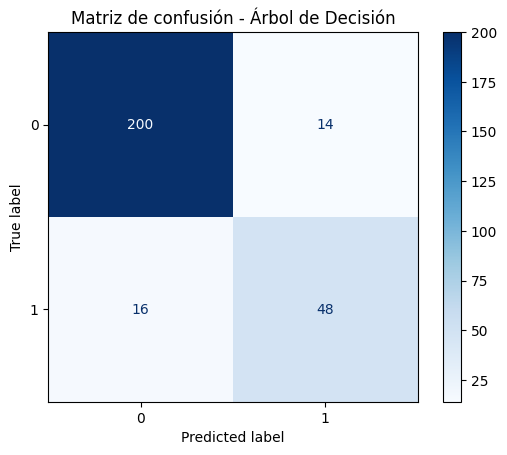

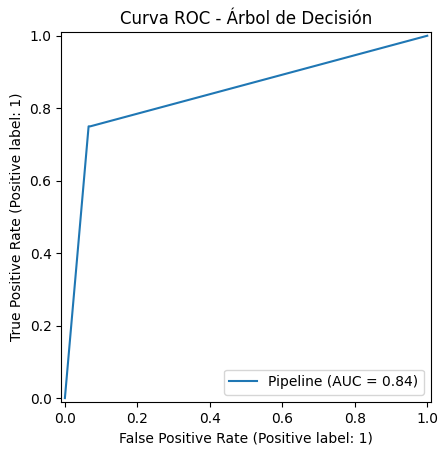

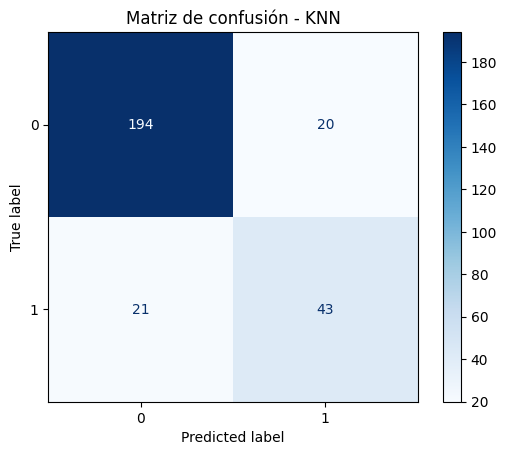

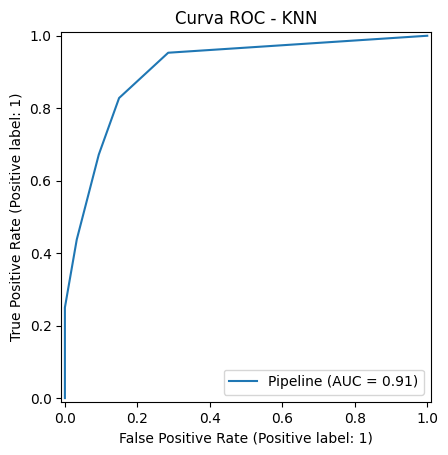

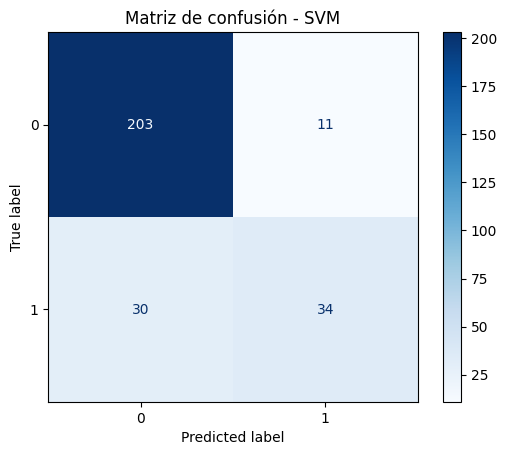

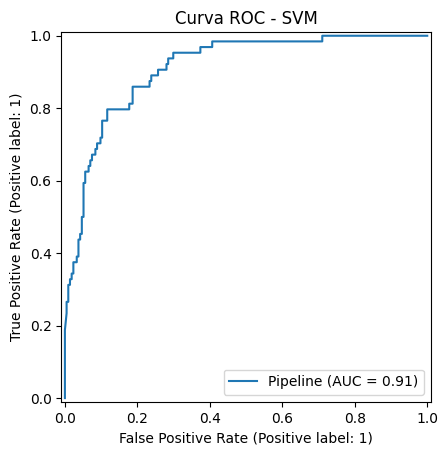

In [42]:
mostrar_matriz_y_roc(
    "Árbol de Decisión",
    DecisionTreeClassifier(random_state=42),
    preprocessor,
    X_train,
    y_train,
    X_test,
    y_test
)

mostrar_matriz_y_roc(
    "KNN",
    KNeighborsClassifier(),
    preprocessor,
    X_train,
    y_train,
    X_test,
    y_test
)

mostrar_matriz_y_roc(
    "SVM",
    SVC(probability=True, random_state=42),
    preprocessor,
    X_train,
    y_train,
    X_test,
    y_test
)

# 5 Modelos Con Hiperparametros

Una vez evaluados los modelos base, se realizó una etapa de optimización de hiperparámetros con el objetivo de mejorar su desempeño predictivo. Para ello, se utilizó GridSearchCV, integrando en cada caso el preprocesamiento y el clasificador dentro de un mismo Pipeline. De esta manera, cada combinación de hiperparámetros fue evaluada bajo el mismo esquema de validación cruzada estratificada empleado previamente.

Los modelos optimizados fueron regresión logística, KNN, Naive Bayes, SVM y árbol de decisión. En cada caso se definió una malla de hiperparámetros acorde con la naturaleza del clasificador. La selección de la mejor configuración se realizó con base en la métrica F1-score, debido a que proporciona un equilibrio entre precisión y recall, lo cual resulta especialmente relevante en un problema de clasificación con desbalance moderado entre clases.

Posteriormente, los mejores modelos obtenidos fueron evaluados sobre el conjunto de prueba para comparar su desempeño frente a las versiones base y seleccionar la alternativa final más adecuada.

### HIPERPARAMETROS

In [43]:
modelos_hiper = {
    "Regresión Logística": { #para que el GridSearchCV sepa que el modelo se llama "model" dentro del pipeline
        "model": LogisticRegression(max_iter=1000, random_state=42), #el modelo base sin hiperparámetros para que el GridSearchCV lo modifique
        "params": { # los hiperparámetros que queremos probar en el GridSearchCV
            "selector__k": [5, 8, 10, "all"],
            "model__C": [0.01, 0.1, 1, 10, 100], #la fuerza de regularización, valores más bajos significan más regularización
            "model__penalty": ["l2"], # L1 no es compatible con el solver lbfgs, por eso solo probamos L2
            "model__solver": ["lbfgs"] # el algoritmo de optimización, lbfgs es bueno para problemas pequeños-medianos y es compatible con L2
        }
    },
    
    "KNN": {
        "model": KNeighborsClassifier(), # el modelo base sin hiperparámetros para que el GridSearchCV lo modifique
        "params": { 
            "selector__k": [5, 8, 10, "all"],
            "model__n_neighbors": [3, 5, 7, 9, 11], #número de vecinos a considerar, valores impares para evitar empates
            "model__weights": ["uniform", "distance"],  #uniform da el mismo peso a todos los vecinos, 
                                                        #distance da más peso a los vecinos más cercanos
            "model__metric": ["euclidean", "manhattan"] #la métrica de distancia, euclidean es la distancia estándar, 
                                                        #manhattan puede ser mejor si hay outliers
        }
    },
    
    "Naive Bayes": {
        "model": GaussianNB(),# el modelo base sin hiperparámetros para que el GridSearchCV lo modifique
        "params": {
            "selector__k": [5, 8, 10, "all"],
            "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]# la varianza de suavizado para evitar problemas de probabilidad cero, valores más altos pueden hacer el modelo más conservador
        }
    },
    
    "SVM": {
        "model": SVC(probability=True, random_state=42),# el modelo base sin hiperparámetros para que el GridSearchCV lo modifique
        "params": {
            "selector__k": [5, 8, 10, "all"],
            "model__C": [0.1, 1, 10, 100],# la fuerza de regularización, valores más bajos significan más regularización
            "model__kernel": ["linear", "rbf"],# el tipo de kernel, linear es bueno para datos linealmente separables, rbf puede capturar relaciones no lineales
            "model__gamma": ["scale", "auto"]# la influencia de cada punto de entrenamiento, scale es 1/n_features, auto es 1/n_samples
        }
    },
    
    "Árbol de Decisión": {
        "model": DecisionTreeClassifier(random_state=42), # el modelo base sin hiperparámetros para que el GridSearchCV lo modifique
        "params": {
            "selector__k": [5, 8, 10, "all"],
            "model__criterion": ["gini", "entropy"], #la función de evaluación para dividir los nodos, gini es la impureza de Gini, entropy es la ganancia de información
            "model__max_depth": [3,5,7],#[None, 3, 5, 10, 15], # la profundidad máxima del árbol, None significa sin límite, valores más bajos pueden prevenir el sobreajuste
            "model__min_samples_split": [5, 10, 15, 20],#[2, 5, 10] # el número mínimo de muestras necesarias para dividir un nodo, valores más altos pueden prevenir el sobreajuste
            "model__min_samples_leaf": [2, 4, 6, 8],#[1, 2, 4]# el número mínimo de muestras necesarias para estar en un nodo hoja, valores más altos pueden prevenir el sobreajuste
            "model__ccp_alpha": [0.0, 0.001, 0.005, 0.01, 0.02]
        }
    },
    "Perceptrón": {
        "model": Perceptron(random_state=42),
        "params": {
            "selector__k": [5, 8, 10, "all"], # para que el GridSearchCV sepa que el selector de características se llama "selector" dentro del pipeline
            "model__penalty": [None, "l2", "l1", "elasticnet"], # el tipo de regularización, None significa sin regularización, l2 es la regularización Ridge, l1 es la regularización Lasso, elasticnet es una combinación de ambas
            "model__alpha": [0.0001, 0.001, 0.01], # la tasa de aprendizaje para la regularización, valores más altos pueden hacer el modelo más conservador
            "model__max_iter": [1000, 2000], # el número máximo de iteraciones para el entrenamiento, valores más altos pueden permitir que el modelo converja mejor
            "model__eta0": [0.001, 0.01, 0.1], # la tasa de aprendizaje inicial, valores más altos pueden hacer que el modelo aprenda más rápido pero también pueden causar inestabilidad
            "model__early_stopping": [True], # si se detiene el entrenamiento temprano si no hay mejora en la validación, puede prevenir el sobreajuste
            "model__validation_fraction": [0.1]# la proporción de datos de entrenamiento a usar como conjunto de validación para el early stopping, valores más altos pueden hacer que el modelo sea más conservador
        }
    }
    
}

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

In [45]:
def optimizar_modelos(modelos_hiper, preprocessor, X_train, y_train, cv, scoring="f1"):
    resultados_grid = []
    mejores_modelos = {}
    
    for nombre, config in modelos_hiper.items():
        print(f"Optimizando {nombre}...")
        
        # pipeline que incluye preprocesamiento, selección de características y el modelo con hiperparámetros a optimizar
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("selector", SelectKBest(score_func=f_classif)),
            ("model", config["model"])
        ])
        
        # GridSearchCV para encontrar los mejores hiperparámetros 
        # según la métrica de scoring, usando validación cruzada cv
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=config["params"],
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )
        
        #entrenar el GridSearchCV para encontrar los mejores hiperparámetros
        grid.fit(X_train, y_train)
        
        
        #guardar los resultados del GridSearchCV en una lista para luego convertirla en DataFrame
        resultados_grid.append({
            "Modelo": nombre,
            "Mejor score CV": grid.best_score_,
            "Mejores hiperparámetros": grid.best_params_
        })
        
        mejores_modelos[nombre] = grid.best_estimator_
    
    df_grid = pd.DataFrame(resultados_grid).sort_values(by="Mejor score CV", ascending=False)
    return df_grid, mejores_modelos

In [46]:
df_hiperparametros, mejores_modelos = optimizar_modelos(
    modelos_hiper=modelos_hiper,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring="f1"
)

print(df_hiperparametros.to_string())

Optimizando Regresión Logística...
Optimizando KNN...
Optimizando Naive Bayes...
Optimizando SVM...
Optimizando Árbol de Decisión...
Optimizando Perceptrón...
                Modelo  Mejor score CV                                                                                                                                                                 Mejores hiperparámetros
4    Árbol de Decisión        0.738285                      {'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 8, 'model__min_samples_split': 5, 'selector__k': 'all'}
3                  SVM        0.731091                                                                                                 {'model__C': 100, 'model__gamma': 'auto', 'model__kernel': 'rbf', 'selector__k': 'all'}
1                  KNN        0.705517                                                                              {'model__metric': 'euclidean', 'model__n_neighbors': 3, 

#### Resultados de los hiperparametros

In [47]:
pd.set_option("display.max_colwidth", None) # para mostrar todo el texto de los hiperparámetros sin truncar
pd.set_option("display.max_columns", None) # para mostrar todas las columnas sin truncar
pd.set_option("display.width", None) # para evitar truncar la tabla en la consola

df_hiperparametros

,Modelo,Mejor score CV,Mejores hiperparámetros
4,Árbol de Decisión,0.738285,"{'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 8, 'model__min_samples_split': 5, 'selector__k': 'all'}"
3,SVM,0.731091,"{'model__C': 100, 'model__gamma': 'auto', 'model__kernel': 'rbf', 'selector__k': 'all'}"
1,KNN,0.705517,"{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform', 'selector__k': 'all'}"
5,Perceptrón,0.571972,"{'model__alpha': 0.001, 'model__early_stopping': True, 'model__eta0': 0.001, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__validation_fraction': 0.1, 'selector__k': 'all'}"
0,Regresión Logística,0.563121,"{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'selector__k': 'all'}"
2,Naive Bayes,0.437060,"{'model__var_smoothing': 1e-09, 'selector__k': 5}"


### TRAIN

In [48]:
def evaluar_solo_train(nombre_modelo, modelo_entrenado, X_train, y_train):
    y_pred_train = modelo_entrenado.predict(X_train)
    
    # Calcular ROC-AUC en el conjunto de entrenamiento 
    # si el modelo tiene predict_proba o decision_function
    if hasattr(modelo_entrenado, "predict_proba"):
        y_score_train = modelo_entrenado.predict_proba(X_train)[:, 1]
        roc_auc_train = roc_auc_score(y_train, y_score_train)
    elif hasattr(modelo_entrenado, "decision_function"):
        y_score_train = modelo_entrenado.decision_function(X_train)
        roc_auc_train = roc_auc_score(y_train, y_score_train)
    else:
        roc_auc_train = np.nan
    
    resultados = pd.DataFrame({
        "Modelo": [nombre_modelo],
        "Accuracy": [accuracy_score(y_train, y_pred_train)],
        "Precision": [precision_score(y_train, y_pred_train)],
        "Recall": [recall_score(y_train, y_pred_train)],
        "F1-score": [f1_score(y_train, y_pred_train)],
        "ROC-AUC": [roc_auc_train]
    })
    
    return resultados

In [49]:
#mostrar los resultados de train para cada 
#modelo con los mejores hiperparámetros encontrados en el GridSearchCV
resultados_train = []

for nombre, modelo in mejores_modelos.items():
    df_temp = evaluar_solo_train(nombre, modelo, X_train, y_train)
    resultados_train.append(df_temp)

df_resultados_train = pd.concat(resultados_train, ignore_index=True)
print("Resultados TRAIN modelos con hiperparametros")
df_resultados_train

Resultados TRAIN modelos con hiperparametros


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.847473,0.743017,0.519531,0.611494,0.909622
1,KNN,0.942238,0.890244,0.855469,0.872510,0.982408
2,Naive Bayes,0.803249,0.637681,0.343750,0.446701,0.858408
3,SVM,0.933213,0.847328,0.867188,0.857143,0.978999
4,Árbol de Decisión,0.902527,0.786822,0.792969,0.789883,0.960621
5,Perceptrón,0.814982,0.664516,0.402344,0.501217,0.792315


In [50]:
#variables categóricas y sus valores únicos
print(sorted(X_train["FiberType"].dropna().unique()))

['0', 'BF', 'CF', 'CF+PP', 'CF+SF', 'CL+PP', 'FF', 'JF', 'LLDPE', 'NY', 'NY+PP', 'PA', 'PE', 'PET', 'PP', 'PP+NY', 'PP+PE', 'PP+PP', 'PVA', 'PVA+PP', 'SF', 'SF+BF', 'SF+FF', 'SF+PE', 'SF+PP', 'SF+PVA', 'SF+SF+PP', 'SF+SF+PVA', 'UHMWPE']


### TEST

In [51]:
def evaluar_mejores_modelos_test(mejores_modelos, X_test, y_test):
    resultados_test = []
    
    for nombre, modelo in mejores_modelos.items():
        y_pred = modelo.predict(X_test)
        
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        elif hasattr(modelo, "decision_function"):
            y_score = modelo.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)
        else:
            roc_auc = np.nan
        
        resultados_test.append({
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc
        })
    
    return pd.DataFrame(resultados_test).sort_values(by="F1-score", ascending=False)

In [52]:
df_test_optimizado = evaluar_mejores_modelos_test(
    mejores_modelos=mejores_modelos,
    X_test=X_test,
    y_test=y_test
)

In [ ]:
df_test_optimizado

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,SVM,0.859712,0.676056,0.750000,0.711111,0.928337
1,KNN,0.863309,0.696970,0.718750,0.707692,0.889530
4,Árbol de Decisión,0.841727,0.651515,0.671875,0.661538,0.891100
0,Regresión Logística,0.859712,0.790698,0.531250,0.635514,0.914464
5,Perceptrón,0.823741,0.702703,0.406250,0.514851,0.724007
2,Naive Bayes,0.798561,0.633333,0.296875,0.404255,0.855761


sobreajuste fuerte: train muy alto, test cae mucho

sobreajuste moderado: train mejor que test, pero test sigue siendo bueno

sin sobreajuste claro: train y test parecidos

subajuste o bajo desempeño: train y test ambos bajos

## Matrices y Curva de ROC

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def mostrar_matrices_confusion_optimizado(mejores_modelos, X_test, y_test):
    n_modelos = len(mejores_modelos)
    fig, axes = plt.subplots(1, n_modelos, figsize=(2 * n_modelos, 4))
    
    if n_modelos == 1:
        axes = [axes]
    
    for ax, (nombre, modelo) in zip(axes, mejores_modelos.items()):
        y_pred = modelo.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(nombre)
    
    plt.suptitle("Matrices de confusión - Modelos con hiperparámetros")
    plt.tight_layout()
    plt.show()

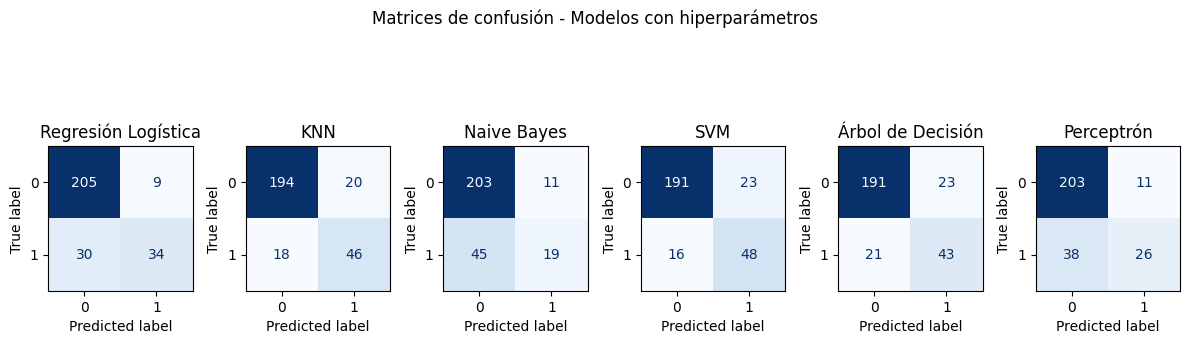

In [54]:
mostrar_matrices_confusion_optimizado(mejores_modelos, X_test, y_test)

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

def mostrar_curvas_roc_optimizado(mejores_modelos, X_test, y_test):
    plt.figure(figsize=(8, 6))
    
    for nombre, modelo in mejores_modelos.items():
        RocCurveDisplay.from_estimator(
            modelo,
            X_test,
            y_test,
            name=nombre
        )
    
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("Comparación de curvas ROC - Modelos optimizados")
    plt.show()

<Figure size 800x600 with 0 Axes>

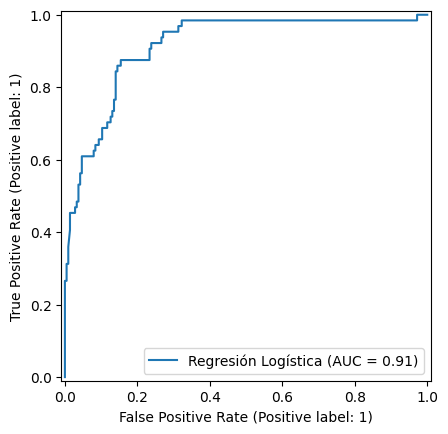

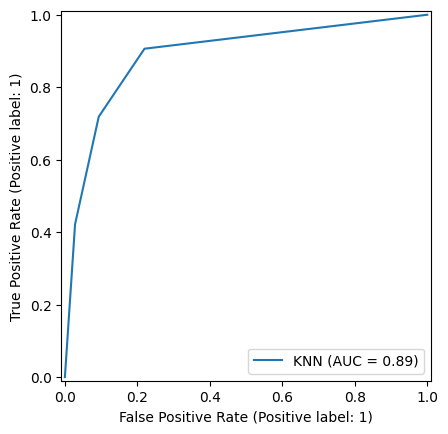

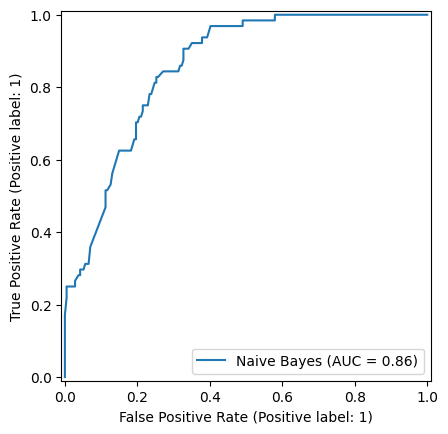

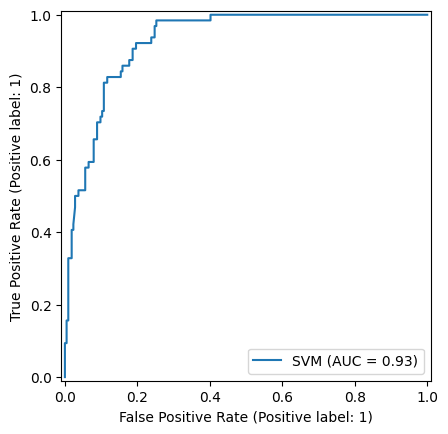

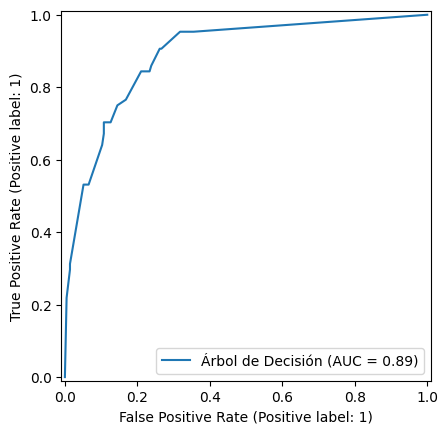

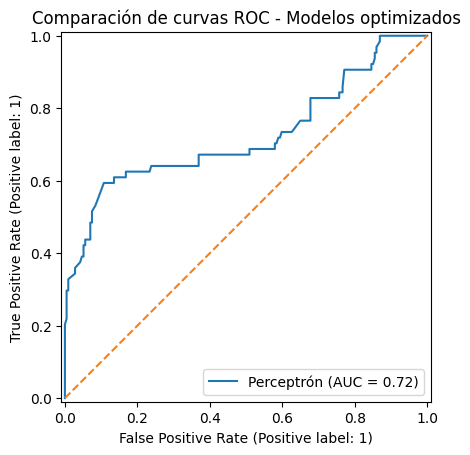

In [56]:
mostrar_curvas_roc_optimizado(mejores_modelos, X_test, y_test)

## Conclusión 

Después de la optimización de hiperparámetros, el modelo SVM presentó el mejor desempeño sobre el conjunto de prueba, alcanzando un F1-score de 0.7111, un recall de 0.7500 y un ROC-AUC de 0.9283. Aunque otros modelos como KNN y árbol de decisión también mostraron resultados competitivos, SVM logró el mejor equilibrio entre capacidad de detección de la clase positiva y desempeño global en datos no vistos. Por esta razón, se seleccionó como el modelo final para la clasificación de la ocurrencia de spalling en concreto.

# Guardar Modelos

In [59]:
#import joblib
#import os

#os.makedirs("modelos_guardados", exist_ok=True)

#for nombre, modelo in mejores_modelos.items():
#    nombre_archivo = nombre.replace(" ", "_").replace("ó", "o").replace("á", "a")
#    joblib.dump(modelo, f"modelos_guardados/{nombre_archivo}.pkl")